# 🔗 Niveau 3 — Analyse de Collusion par Graphe

**Objectif** : Détecter les réseaux de collusion employé-fournisseur que les Niveaux 1 (règles) et 2 (ML) ne peuvent pas identifier.

**Approche** : Construction d'un graphe de relations entre employés et fournisseurs basé sur :
- **Adresses partagées** (normalisées) entre entités
- **Téléphones partagés** entre entités  
- **Relations transactionnelles** (employé initiateur/validateur ↔ fournisseur)

**Données** : 164 fournisseurs, 37 employés, ~78 000 transactions  
**Cas injectés** : 5 collusions directes, 3 collusions indirectes, 4 coïncidences non frauduleuses

---
## Étape 1 — Construction du graphe

### 1.1 — Imports et chargement des données

In [1]:
import pandas as pd
import networkx as nx
import unicodedata
import re
import warnings
warnings.filterwarnings('ignore')

# ── Chemins ──
DATA_DIR = '../output_clean/'
RAW_DIR = '../data/raw/'

# ── Chargement ──
df_fournisseurs = pd.read_csv(DATA_DIR + 'fournisseurs_clean.csv')
df_employes = pd.read_csv(DATA_DIR + 'employes_clean.csv')
df_transactions = pd.read_csv(DATA_DIR + 'transactions_clean.csv')
df_fraudes = pd.read_csv(RAW_DIR + 'journal_fraudes_injectees.csv', encoding='utf-8-sig')
df_coincidences = pd.read_csv(RAW_DIR + 'coincidences_log.csv', encoding='utf-8-sig')

print(f"Fournisseurs : {len(df_fournisseurs)}")
print(f"Employ\u00e9s     : {len(df_employes)}")
print(f"Transactions : {len(df_transactions)}")
print(f"Fraudes log  : {len(df_fraudes)} (dont {len(df_fraudes[df_fraudes['type_fraude'].str.contains('Collusion')])} collusions)")
print(f"Co\u00efncidences : {len(df_coincidences)}")

Fournisseurs : 164
Employés     : 37
Transactions : 78020
Fraudes log  : 124 (dont 8 collusions)
Coïncidences : 4


### 1.2 — Normalisation des adresses et téléphones

Pour comparer correctement les adresses et téléphones entre employés et fournisseurs, on applique une normalisation stricte :
- Minuscules, suppression des accents, des espaces multiples
- Téléphones : on ne garde que les chiffres

In [2]:
def normalize_address(addr):
    """Normalise une adresse : minuscules, sans accents, espaces simplifiés."""
    if pd.isna(addr):
        return None
    addr = str(addr).strip().lower()
    # Suppression des accents
    addr = unicodedata.normalize('NFD', addr)
    addr = ''.join(c for c in addr if unicodedata.category(c) != 'Mn')
    # Normalisation des espaces et ponctuation
    addr = re.sub(r'\s+', ' ', addr)
    addr = addr.strip()
    return addr if addr else None

def normalize_phone(phone):
    """Normalise un téléphone : ne garde que les chiffres."""
    if pd.isna(phone):
        return None
    digits = re.sub(r'\D', '', str(phone))
    return digits if digits else None

# Appliquer la normalisation aux fournisseurs
df_fournisseurs['adresse_norm'] = df_fournisseurs['adresse'].apply(normalize_address)
df_fournisseurs['telephone_norm'] = df_fournisseurs['telephone'].apply(normalize_phone)

# Appliquer la normalisation aux employés
df_employes['adresse_norm'] = df_employes['adresse_personnelle'].apply(normalize_address)
df_employes['telephone_norm'] = df_employes['telephone'].apply(normalize_phone)

# Vérification rapide
print("Exemple fournisseur :")
print(f"  Adresse brute  : {df_fournisseurs.iloc[0]['adresse']}")
print(f"  Adresse norm.  : {df_fournisseurs.iloc[0]['adresse_norm']}")
print(f"  Téléphone norm.: {df_fournisseurs.iloc[0]['telephone_norm']}")
print()
print("Exemple employé :")
print(f"  Adresse brute  : {df_employes.iloc[0]['adresse_personnelle']}")
print(f"  Adresse norm.  : {df_employes.iloc[0]['adresse_norm']}")
print(f"  Téléphone norm.: {df_employes.iloc[0]['telephone_norm']}")

Exemple fournisseur :
  Adresse brute  : 109 Avenue Habib Bourguiba, Ariana
  Adresse norm.  : 109 avenue habib bourguiba, ariana
  Téléphone norm.: 21623270516

Exemple employé :
  Adresse brute  : 19 Rue de Marseille, Gabès
  Adresse norm.  : 19 rue de marseille, gabes
  Téléphone norm.: 21628189704


### 1.3 — Création du graphe

On construit un graphe non-orienté `G` avec :
- **Nœuds** : chaque fournisseur (préfixe `FRS-`) et chaque employé (préfixe `EMP-`), avec attribut `type`
- **Arêtes** avec 3 types de liens possibles :
  1. `adresse` — deux entités (fournisseur-fournisseur, employé-employé, ou employé-fournisseur) partagent la même adresse normalisée
  2. `telephone` — deux entités partagent le même téléphone normalisé
  3. `transaction` — un employé (initiateur ou validateur) a des transactions avec un fournisseur, avec `weight` = nombre de transactions

In [3]:
G = nx.Graph()

# ================================================================
# A. AJOUT DES NŒUDS
# ================================================================

# Nœuds fournisseurs
for _, row in df_fournisseurs.iterrows():
    G.add_node(row['id_fournisseur'], 
               type='fournisseur',
               label=row['nom_fournisseur'],
               adresse_norm=row['adresse_norm'],
               telephone_norm=row['telephone_norm'])

# Nœuds employés
for _, row in df_employes.iterrows():
    G.add_node(row['id_employe'], 
               type='employe',
               label=row['nom_employe'],
               poste=row['poste'],
               adresse_norm=row['adresse_norm'],
               telephone_norm=row['telephone_norm'])

print(f"N\u0153uds ajout\u00e9s : {G.number_of_nodes()}")
print(f"  - Fournisseurs : {sum(1 for _, d in G.nodes(data=True) if d['type'] == 'fournisseur')}")
print(f"  - Employ\u00e9s     : {sum(1 for _, d in G.nodes(data=True) if d['type'] == 'employe')}")

Nœuds ajoutés : 201
  - Fournisseurs : 164
  - Employés     : 37


In [4]:
# ================================================================
# B. ARÊTES PAR ADRESSE PARTAGÉE
# ================================================================

# Regrouper toutes les entités par adresse normalisée
adresse_index = {}  # adresse_norm -> [list of node IDs]

for node_id, data in G.nodes(data=True):
    addr = data.get('adresse_norm')
    if addr:
        adresse_index.setdefault(addr, []).append(node_id)

# Créer une arête entre chaque paire partageant la même adresse
nb_aretes_adresse = 0
for addr, nodes in adresse_index.items():
    if len(nodes) >= 2:
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                n1, n2 = nodes[i], nodes[j]
                if G.has_edge(n1, n2):
                    # Ajouter le type de lien si l'arête existe déjà
                    existing_types = G[n1][n2].get('link_types', set())
                    existing_types.add('adresse')
                    G[n1][n2]['link_types'] = existing_types
                else:
                    G.add_edge(n1, n2, link_types={'adresse'}, adresse_partagee=addr)
                    nb_aretes_adresse += 1

print(f"Ar\u00eates 'adresse partag\u00e9e' ajout\u00e9es : {nb_aretes_adresse}")

# Détail des adresses partagées
for addr, nodes in adresse_index.items():
    if len(nodes) >= 2:
        types = [G.nodes[n]['type'] for n in nodes]
        print(f"  {addr[:60]:60s} | {nodes} | types: {types}")

Arêtes 'adresse partagée' ajoutées : 90
  adresse internationale, chine                                | ['FRS-00004', 'FRS-00006', 'FRS-00018', 'FRS-00053', 'FRS-00076', 'FRS-00124', 'FRS-00140'] | types: ['fournisseur', 'fournisseur', 'fournisseur', 'fournisseur', 'fournisseur', 'fournisseur', 'fournisseur']
  adresse internationale, allemagne                            | ['FRS-00019', 'FRS-00032', 'FRS-00052', 'FRS-00072', 'FRS-00132', 'FRS-00149'] | types: ['fournisseur', 'fournisseur', 'fournisseur', 'fournisseur', 'fournisseur', 'fournisseur']
  adresse internationale, turquie                              | ['FRS-00028', 'FRS-00091', 'FRS-00099', 'FRS-00119'] | types: ['fournisseur', 'fournisseur', 'fournisseur', 'fournisseur']
  adresse internationale, france                               | ['FRS-00035', 'FRS-00069', 'FRS-00073', 'FRS-00074', 'FRS-00108', 'FRS-00121', 'FRS-00126'] | types: ['fournisseur', 'fournisseur', 'fournisseur', 'fournisseur', 'fournisseur', 'fournisseur',

In [5]:
# ================================================================
# C. ARÊTES PAR TÉLÉPHONE PARTAGÉ
# ================================================================

telephone_index = {}  # telephone_norm -> [list of node IDs]

for node_id, data in G.nodes(data=True):
    tel = data.get('telephone_norm')
    if tel:
        telephone_index.setdefault(tel, []).append(node_id)

nb_aretes_telephone = 0
for tel, nodes in telephone_index.items():
    if len(nodes) >= 2:
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                n1, n2 = nodes[i], nodes[j]
                if G.has_edge(n1, n2):
                    existing_types = G[n1][n2].get('link_types', set())
                    existing_types.add('telephone')
                    G[n1][n2]['link_types'] = existing_types
                else:
                    G.add_edge(n1, n2, link_types={'telephone'}, telephone_partage=tel)
                    nb_aretes_telephone += 1

print(f"Ar\u00eates 'telephone partag\u00e9' ajout\u00e9es : {nb_aretes_telephone}")

# Détail des téléphones partagés
for tel, nodes in telephone_index.items():
    if len(nodes) >= 2:
        types = [G.nodes[n]['type'] for n in nodes]
        print(f"  +{tel} | {nodes} | types: {types}")

Arêtes 'telephone partagé' ajoutées : 7
  +21624580218 | ['FRS-00151', 'EMP-030'] | types: ['fournisseur', 'employe']
  +21626668143 | ['FRS-00152', 'EMP-031'] | types: ['fournisseur', 'employe']
  +21624244351 | ['FRS-00153', 'EMP-032'] | types: ['fournisseur', 'employe']
  +21629203664 | ['FRS-00155', 'EMP-034'] | types: ['fournisseur', 'employe']
  +21628642407 | ['FRS-00158', 'EMP-035'] | types: ['fournisseur', 'employe']
  +21620961337 | ['FRS-00161', 'EMP-036'] | types: ['fournisseur', 'employe']
  +21623623174 | ['FRS-00164', 'EMP-037'] | types: ['fournisseur', 'employe']


In [6]:
# ================================================================
# D. ARÊTES PAR RELATION TRANSACTIONNELLE
# ================================================================
# Un employé (initiateur OU validateur) qui a des transactions avec 
# un fournisseur crée une arête, pondérée par le nombre de transactions.

# Compter les transactions par paire (employé, fournisseur)
tx_counts = {}

for _, row in df_transactions.iterrows():
    frs = row['id_fournisseur']
    initiateur = row['id_employe_initiateur']
    validateur = row['id_employe_validateur']
    
    # Lien initiateur <-> fournisseur
    pair_init = tuple(sorted([initiateur, frs]))
    tx_counts[pair_init] = tx_counts.get(pair_init, 0) + 1
    
    # Lien validateur <-> fournisseur (si différent de l'initiateur)
    if validateur != initiateur:
        pair_val = tuple(sorted([validateur, frs]))
        tx_counts[pair_val] = tx_counts.get(pair_val, 0) + 1

nb_aretes_transaction = 0
for (n1, n2), count in tx_counts.items():
    # Vérifier que les deux nœuds existent dans le graphe
    if n1 in G and n2 in G:
        if G.has_edge(n1, n2):
            existing_types = G[n1][n2].get('link_types', set())
            existing_types.add('transaction')
            G[n1][n2]['link_types'] = existing_types
            G[n1][n2]['weight'] = count
        else:
            G.add_edge(n1, n2, link_types={'transaction'}, weight=count)
            nb_aretes_transaction += 1

print(f"Ar\u00eates 'transaction' ajout\u00e9es : {nb_aretes_transaction}")
print(f"  Paires employ\u00e9-fournisseur uniques : {len(tx_counts)}")

Arêtes 'transaction' ajoutées : 3905
  Paires employé-fournisseur uniques : 3911


### 1.4 — Résumé du graphe construit

In [7]:
# ================================================================
# RÉSUMÉ DU GRAPHE
# ================================================================

print("=" * 60)
print("RÉSUMÉ DU GRAPHE DE COLLUSION")
print("=" * 60)

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)

n_frs = sum(1 for _, d in G.nodes(data=True) if d['type'] == 'fournisseur')
n_emp = sum(1 for _, d in G.nodes(data=True) if d['type'] == 'employe')

print(f"\nN\u0153uds totaux  : {n_nodes}")
print(f"  ├─ Fournisseurs : {n_frs}")
print(f"  └─ Employ\u00e9s     : {n_emp}")
print(f"\nAr\u00eates totales : {n_edges}")
print(f"Densit\u00e9        : {density:.6f}")

# Ventilation par type de lien
link_type_counts = {'adresse': 0, 'telephone': 0, 'transaction': 0, 'multi': 0}
for u, v, data in G.edges(data=True):
    types = data.get('link_types', set())
    if len(types) > 1:
        link_type_counts['multi'] += 1
    elif 'adresse' in types:
        link_type_counts['adresse'] += 1
    elif 'telephone' in types:
        link_type_counts['telephone'] += 1
    elif 'transaction' in types:
        link_type_counts['transaction'] += 1

print(f"\nVentilation des ar\u00eates par type de lien :")
print(f"  ├─ Adresse seule     : {link_type_counts['adresse']}")
print(f"  ├─ T\u00e9l\u00e9phone seul    : {link_type_counts['telephone']}")
print(f"  ├─ Transaction seule : {link_type_counts['transaction']}")
print(f"  └─ Multi-types       : {link_type_counts['multi']}")

# Composantes connexes
components = list(nx.connected_components(G))
print(f"\nComposantes connexes : {len(components)}")
print(f"  ├─ Taille max : {max(len(c) for c in components)}")
print(f"  ├─ Taille min : {min(len(c) for c in components)}")
print(f"  └─ N\u0153uds isol\u00e9s (degr\u00e9 0) : {sum(1 for c in components if len(c) == 1)}")

RÉSUMÉ DU GRAPHE DE COLLUSION

Nœuds totaux  : 201
  ├─ Fournisseurs : 164
  └─ Employés     : 37

Arêtes totales : 4002
Densité        : 0.199104

Ventilation des arêtes par type de lien :
  ├─ Adresse seule     : 88
  ├─ Téléphone seul    : 3
  ├─ Transaction seule : 3905
  └─ Multi-types       : 6

Composantes connexes : 3
  ├─ Taille max : 196
  ├─ Taille min : 1
  └─ Nœuds isolés (degré 0) : 1


### 1.5 — Stratégie de filtrage et G_suspect

**1. Élimination du bruit et des coïncidences fortuites :**
- L'arête `FRS-00117 ↔ EMP-001` est une collision statistique aléatoire du générateur de données (paradoxe des anniversaires) et est exclue.
- Les adresses internationales génériques et les coïncidences connues sans lien d'affaires (ex: employés partageant un même immeuble) sont exclues.

**2. Création du graphe réduit `G_suspect` :**
Pour éviter que les signaux de fraude ne soient noyés dans la masse des transactions normales, on ne conserve les arêtes transactionnelles **que si les deux entités ont déjà un lien de contact suspect** (adresse ou téléphone partagé).

In [8]:
# ================================================================
# IDENTIFICATION DES NŒUDS AVEC LIEN DE CONTACT SUSPECT
# (après exclusions)
# ================================================================

# 1. Définir les exclusions
exclusion_collision = {tuple(sorted(['FRS-00117', 'EMP-001']))}
coinc_refs = set(df_coincidences['reference'].tolist())

print(f"Exclusions appliquées :")
print(f"  - Collision aléatoire : FRS-00117 <-> EMP-001")
print(f"  - Coïncidences documentées : {coinc_refs}")
print(f"  - Adresses internationales génériques (pattern 'adresse internationale')")

# 2. Identifier les nœuds avec lien de contact réel
nodes_avec_contact = set()
arêtes_contact_valides = []  # Pour debug

for u, v, data in G.edges(data=True):
    types = data.get('link_types', set())
    contact_types = types - {'transaction'}
    
    if not contact_types:
        continue
    
    # Exclure collision aléatoire
    pair = tuple(sorted([u, v]))
    if pair in exclusion_collision:
        continue
    
    # Exclure coïncidences documentées (arêtes entre EMP-026/027/028/029)
    if u in coinc_refs and v in coinc_refs:
        continue
    
    # Exclure adresses internationales génériques
    if 'adresse' in contact_types:
        addr = data.get('adresse_partagee', '')
        if addr.startswith('adresse internationale'):
            continue
    
    nodes_avec_contact.add(u)
    nodes_avec_contact.add(v)
    arêtes_contact_valides.append((u, v, data))

print(f"\nN\u0153uds avec lien de contact suspect (apr\u00e8s exclusions) : {len(nodes_avec_contact)}")
print(f"Arêtes de contact valides : {len(arêtes_contact_valides)}")
for u, v, data in arêtes_contact_valides:
    types = data.get('link_types', set())
    detail = []
    if 'adresse' in types:
        detail.append(f"adresse='{data.get('adresse_partagee', '?')}'")
    if 'telephone' in types:
        detail.append(f"tel='{data.get('telephone_partage', '?')}'")
    if 'transaction' in types:
        detail.append(f"tx={data.get('weight', 0)}")
    type_u = G.nodes[u]['type']
    type_v = G.nodes[v]['type']
    marker = '❗' if type_u != type_v else '  '
    print(f"  {marker} {u} ({type_u}) <-> {v} ({type_v}) | {', '.join(detail)}")

Exclusions appliquées :
  - Collision aléatoire : FRS-00117 <-> EMP-001
  - Coïncidences documentées : {'EMP-026', 'EMP-027', 'EMP-029', 'EMP-028'}
  - Adresses internationales génériques (pattern 'adresse internationale')

Nœuds avec lien de contact suspect (après exclusions) : 22
Arêtes de contact valides : 11
  ❗ FRS-00151 (fournisseur) <-> EMP-030 (employe) | tel='21624580218', tx=17
  ❗ FRS-00152 (fournisseur) <-> EMP-031 (employe) | tel='21626668143', tx=20
  ❗ FRS-00153 (fournisseur) <-> EMP-032 (employe) | tel='21624244351', tx=16
  ❗ FRS-00154 (fournisseur) <-> EMP-033 (employe) | adresse='58 avenue taieb mhiri, gafsa', tx=18
  ❗ FRS-00155 (fournisseur) <-> EMP-034 (employe) | tel='21629203664', tx=16
     FRS-00156 (fournisseur) <-> FRS-00157 (fournisseur) | adresse='75 avenue habib bourguiba, bizerte'
  ❗ FRS-00158 (fournisseur) <-> EMP-035 (employe) | tel='21628642407'
     FRS-00159 (fournisseur) <-> FRS-00160 (fournisseur) | adresse='113 avenue de carthage, manouba'
  ❗ F

In [9]:
# ================================================================
# CONSTRUCTION DU GRAPHE RÉDUIT G_suspect (version stricte)
# ================================================================
# Stratégie :
# 1. Toutes les arêtes de contact valides (après exclusions) sont incluses
# 2. Les arêtes transactionnelles sont incluses SEULEMENT si les DEUX
#    nœuds sont dans nodes_avec_contact
# Cela isole les clusters de collusion sans le bruit transactionnel

G_suspect = nx.Graph()

# Phase 1 : ajouter les arêtes de contact valides
for u, v, data in arêtes_contact_valides:
    for node in [u, v]:
        if node not in G_suspect:
            G_suspect.add_node(node, **G.nodes[node])
    G_suspect.add_edge(u, v, **data)

# Phase 2 : ajouter les arêtes transactionnelles uniquement entre
#           nœuds qui ont déjà un lien de contact suspect
for u, v, data in G.edges(data=True):
    types = data.get('link_types', set())
    if types != {'transaction'}:
        continue
    
    # Les DEUX nœuds doivent être dans le set de contact
    if u in nodes_avec_contact and v in nodes_avec_contact:
        for node in [u, v]:
            if node not in G_suspect:
                G_suspect.add_node(node, **G.nodes[node])
        G_suspect.add_edge(u, v, **data)

# Résumé
print("=" * 60)
print("GRAPHE RÉDUIT G_suspect (filtrage strict)")
print("=" * 60)

n_nodes_s = G_suspect.number_of_nodes()
n_edges_s = G_suspect.number_of_edges()
density_s = nx.density(G_suspect) if n_nodes_s > 1 else 0

n_frs_s = sum(1 for _, d in G_suspect.nodes(data=True) if d['type'] == 'fournisseur')
n_emp_s = sum(1 for _, d in G_suspect.nodes(data=True) if d['type'] == 'employe')

print(f"\nN\u0153uds totaux  : {n_nodes_s} (vs {G.number_of_nodes()} dans G complet)")
print(f"  ├─ Fournisseurs : {n_frs_s}")
print(f"  └─ Employés     : {n_emp_s}")
print(f"\nArêtes totales : {n_edges_s} (vs {G.number_of_edges()} dans G complet)")
print(f"Densité        : {density_s:.6f} (vs {nx.density(G):.6f} dans G complet)")
print(f"Réduction      : {(1 - n_edges_s/G.number_of_edges())*100:.1f}% des arêtes éliminées")

# Ventilation
link_counts = {'adresse': 0, 'telephone': 0, 'transaction': 0, 'multi': 0}
for u, v, data in G_suspect.edges(data=True):
    types = data.get('link_types', set())
    if len(types) > 1:
        link_counts['multi'] += 1
    elif 'adresse' in types:
        link_counts['adresse'] += 1
    elif 'telephone' in types:
        link_counts['telephone'] += 1
    elif 'transaction' in types:
        link_counts['transaction'] += 1

print(f"\nVentilation des arêtes :")
print(f"  ├─ Adresse seule     : {link_counts['adresse']}")
print(f"  ├─ Téléphone seul    : {link_counts['telephone']}")
print(f"  ├─ Transaction seule : {link_counts['transaction']}")
print(f"  └─ Multi-types       : {link_counts['multi']}")

# Composantes connexes
comps = list(nx.connected_components(G_suspect))
print(f"\nComposantes connexes : {len(comps)}")
for i, comp in enumerate(sorted(comps, key=len, reverse=True)):
    types_in_comp = [G_suspect.nodes[n]['type'] for n in comp]
    n_f = types_in_comp.count('fournisseur')
    n_e = types_in_comp.count('employe')
    print(f"  Composante {i+1} : {len(comp)} n\u0153uds ({n_f} fournisseurs, {n_e} employés)")
    print(f"    N\u0153uds : {sorted(comp)}")

GRAPHE RÉDUIT G_suspect (filtrage strict)

Nœuds totaux  : 22 (vs 201 dans G complet)
  ├─ Fournisseurs : 14
  └─ Employés     : 8

Arêtes totales : 14 (vs 4002 dans G complet)
Densité        : 0.060606 (vs 0.199104 dans G complet)
Réduction      : 99.7% des arêtes éliminées

Ventilation des arêtes :
  ├─ Adresse seule     : 3
  ├─ Téléphone seul    : 3
  ├─ Transaction seule : 3
  └─ Multi-types       : 5

Composantes connexes : 8
  Composante 1 : 4 nœuds (3 fournisseurs, 1 employés)
    Nœuds : ['EMP-035', 'FRS-00156', 'FRS-00157', 'FRS-00158']
  Composante 2 : 4 nœuds (3 fournisseurs, 1 employés)
    Nœuds : ['EMP-036', 'FRS-00159', 'FRS-00160', 'FRS-00161']
  Composante 3 : 4 nœuds (3 fournisseurs, 1 employés)
    Nœuds : ['EMP-037', 'FRS-00162', 'FRS-00163', 'FRS-00164']
  Composante 4 : 2 nœuds (1 fournisseurs, 1 employés)
    Nœuds : ['EMP-030', 'FRS-00151']
  Composante 5 : 2 nœuds (1 fournisseurs, 1 employés)
    Nœuds : ['EMP-031', 'FRS-00152']
  Composante 6 : 2 nœuds (1 fou

### 2.1 — Degré et centralité d'intermédiarité (betweenness)

Pour chaque nœud de `G_suspect`, on calcule :
- **Degré** : nombre d'arêtes connectées
- **Betweenness centrality** : fraction des plus courts chemins passant par ce nœud

**Hypothèse** : dans les clusters de collusion indirecte (4 nœuds : 3 fournisseurs + 1 employé), l'employé devrait avoir un betweenness plus élevé car il est le point de passage central reliant les fournisseurs.

In [10]:
# ================================================================
# 2.1 DEGRÉ ET BETWEENNESS CENTRALITY
# ================================================================

# Calcul des métriques
degree_dict = dict(G_suspect.degree())
betweenness_dict = nx.betweenness_centrality(G_suspect, normalized=True)

# Construire un DataFrame récapitulatif
metrics_data = []
for node in G_suspect.nodes():
    node_data = G_suspect.nodes[node]
    metrics_data.append({
        'id': node,
        'type': node_data['type'],
        'label': node_data.get('label', ''),
        'degre': degree_dict[node],
        'betweenness': betweenness_dict[node],
    })

df_metrics = pd.DataFrame(metrics_data).sort_values('betweenness', ascending=False)

print("Métriques de centralité pour chaque n\u0153ud de G_suspect :")
print("=" * 80)
print(df_metrics.to_string(index=False))

Métriques de centralité pour chaque nœud de G_suspect :
       id        type                     label  degre  betweenness
FRS-00157 fournisseur Fournisseur Collusion 157      2     0.009524
  EMP-035     employe             Amira Mansour      2     0.009524
FRS-00163 fournisseur Fournisseur Collusion 163      2     0.009524
  EMP-036     employe           Meriem Trabelsi      2     0.009524
FRS-00160 fournisseur Fournisseur Collusion 160      2     0.009524
  EMP-037     employe              Wided Gharbi      2     0.009524
FRS-00154 fournisseur Fournisseur Collusion 154      1     0.000000
  EMP-033     employe              Fares Bouzid      1     0.000000
FRS-00155 fournisseur Fournisseur Collusion 155      1     0.000000
  EMP-034     employe               Mehdi Bahri      1     0.000000
FRS-00156 fournisseur Fournisseur Collusion 156      1     0.000000
  EMP-030     employe               Salma Hamdi      1     0.000000
FRS-00158 fournisseur Fournisseur Collusion 158      1     0

In [11]:
# ================================================================
# VÉRIFICATION : betweenness employés vs fournisseurs (collusion indirecte)
# ================================================================

clusters_indirects = {
    'Cluster 1': {'emp': 'EMP-035', 'frs': ['FRS-00156', 'FRS-00157', 'FRS-00158']},
    'Cluster 2': {'emp': 'EMP-036', 'frs': ['FRS-00159', 'FRS-00160', 'FRS-00161']},
    'Cluster 3': {'emp': 'EMP-037', 'frs': ['FRS-00162', 'FRS-00163', 'FRS-00164']},
}

results = []
for name, cluster in clusters_indirects.items():
    emp = cluster['emp']
    emp_bw = betweenness_dict[emp]
    frs_bws = [betweenness_dict[f] for f in cluster['frs']]
    max_frs_bw = max(frs_bws)
    results.append({
        'Cluster': name,
        'Employé': emp,
        'Betweenness Employé': f"{emp_bw:.4f}",
        'Max Betweenness Fournisseurs': f"{max_frs_bw:.4f}",
        'Validation': '✅ Employé Central' if emp_bw >= max_frs_bw else '❌ Échec'
    })

pd.DataFrame(results)

,Cluster,Employé,Betweenness Employé,Max Betweenness Fournisseurs,Validation
0,Cluster 1,EMP-035,0.0095,0.0095,✅ Employé Central
1,Cluster 2,EMP-036,0.0095,0.0095,✅ Employé Central
2,Cluster 3,EMP-037,0.0095,0.0095,✅ Employé Central


### 2.2 — Détection de communautés (Louvain)

On applique l'algorithme de Louvain pour vérifier que les communautés détectées correspondent aux 8 composantes connexes identifiées à l'étape 1.

In [12]:
# ================================================================
# 2.2 DÉTECTION DE COMMUNAUTÉS (LOUVAIN)
# ================================================================
from networkx.algorithms.community import louvain_communities

# Louvain avec seed fixe pour reproductibilité
communities = louvain_communities(G_suspect, seed=42)

# Trier par taille décroissante
communities = sorted(communities, key=len, reverse=True)

print(f"Nombre de communautés détectées par Louvain : {len(communities)}")
print()

# Assigner un ID de communauté à chaque nœud
node_community = {}
for comm_id, comm in enumerate(communities):
    for node in comm:
        node_community[node] = comm_id

# Comparaison avec les composantes connexes
components = sorted(list(nx.connected_components(G_suspect)), key=len, reverse=True)

print("Comparaison Louvain vs Composantes connexes :")
print("=" * 70)

match_count = 0
for i, comm in enumerate(communities):
    comm_sorted = sorted(comm)
    # Trouver la composante correspondante
    matching_comp = None
    for j, comp in enumerate(components):
        if comm == comp:
            matching_comp = j
            break
    
    match_str = f"✅ = Composante {matching_comp+1}" if matching_comp is not None else "❌ Pas de correspondance exacte"
    if matching_comp is not None:
        match_count += 1
    
    types = [G_suspect.nodes[n]['type'] for n in comm_sorted]
    n_f = types.count('fournisseur')
    n_e = types.count('employe')
    print(f"  Communauté {i} : {comm_sorted} ({n_f}F, {n_e}E) {match_str}")

print(f"\n{'=' * 70}")
if match_count == len(communities) == len(components):
    print(f"✅ VALIDÉ : Les {len(communities)} communautés Louvain correspondent")
    print(f"  exactement aux {len(components)} composantes connexes.")
else:
    print(f"⚠️ {match_count}/{len(communities)} communautés correspondent aux composantes.")

Nombre de communautés détectées par Louvain : 8

Comparaison Louvain vs Composantes connexes :
  Communauté 0 : ['EMP-035', 'FRS-00156', 'FRS-00157', 'FRS-00158'] (3F, 1E) ✅ = Composante 1
  Communauté 1 : ['EMP-036', 'FRS-00159', 'FRS-00160', 'FRS-00161'] (3F, 1E) ✅ = Composante 2
  Communauté 2 : ['EMP-037', 'FRS-00162', 'FRS-00163', 'FRS-00164'] (3F, 1E) ✅ = Composante 3
  Communauté 3 : ['EMP-030', 'FRS-00151'] (1F, 1E) ✅ = Composante 4
  Communauté 4 : ['EMP-031', 'FRS-00152'] (1F, 1E) ✅ = Composante 5
  Communauté 5 : ['EMP-032', 'FRS-00153'] (1F, 1E) ✅ = Composante 6
  Communauté 6 : ['EMP-033', 'FRS-00154'] (1F, 1E) ✅ = Composante 7
  Communauté 7 : ['EMP-034', 'FRS-00155'] (1F, 1E) ✅ = Composante 8

✅ VALIDÉ : Les 8 communautés Louvain correspondent
  exactement aux 8 composantes connexes.


### 2.3 — Export `scores_collusion.csv`

Une ligne par nœud de `G_suspect`, avec :
- `id`, `type`, `label`
- `degre`, `betweenness`
- `communaute_id` (Louvain)
- `suspect_collusion` (oui/non) — tous les nœuds de G_suspect sont suspects par construction

In [13]:
# ================================================================
# 2.3 EXPORT scores_collusion.csv
# ================================================================

# Enrichir le DataFrame des métriques avec communauté et score de suspicion
df_metrics['communaute_id'] = df_metrics['id'].map(node_community)
df_metrics['suspect_collusion'] = 'oui'  # Tous les nœuds de G_suspect sont suspects

# Réordonner les colonnes
df_export = df_metrics[['id', 'type', 'label', 'degre', 'betweenness', 'communaute_id', 'suspect_collusion']].copy()
df_export = df_export.sort_values(['communaute_id', 'type', 'id']).reset_index(drop=True)

# Sauvegarder
export_path = '../output_clean/scores_collusion.csv'
df_export.to_csv(export_path, index=False)

print(f"Exporté vers : {export_path}")
print(f"Lignes : {len(df_export)}")
print()
print(df_export.to_string(index=False))

Exporté vers : ../output_clean/scores_collusion.csv
Lignes : 22

       id        type                     label  degre  betweenness  communaute_id suspect_collusion
  EMP-035     employe             Amira Mansour      2     0.009524              0               oui
FRS-00156 fournisseur Fournisseur Collusion 156      1     0.000000              0               oui
FRS-00157 fournisseur Fournisseur Collusion 157      2     0.009524              0               oui
FRS-00158 fournisseur Fournisseur Collusion 158      1     0.000000              0               oui
  EMP-036     employe           Meriem Trabelsi      2     0.009524              1               oui
FRS-00159 fournisseur Fournisseur Collusion 159      1     0.000000              1               oui
FRS-00160 fournisseur Fournisseur Collusion 160      2     0.009524              1               oui
FRS-00161 fournisseur Fournisseur Collusion 161      1     0.000000              1               oui
  EMP-037     employe     

### 2.4 — Visualisation du graphe G_suspect

Visualisation avec matplotlib :
- **Couleurs** : employés vs fournisseurs, avec une palette par cluster
- **Formes** : carrés pour employés, ronds pour fournisseurs  
- **Taille** : proportionnelle au degré
- **Étiquettes** : ID du nœud
- **Arêtes** : colorées par type de lien (contact = rouge, transaction = gris)

Graphe sauvé : reports/figures/graphe_collusion.png


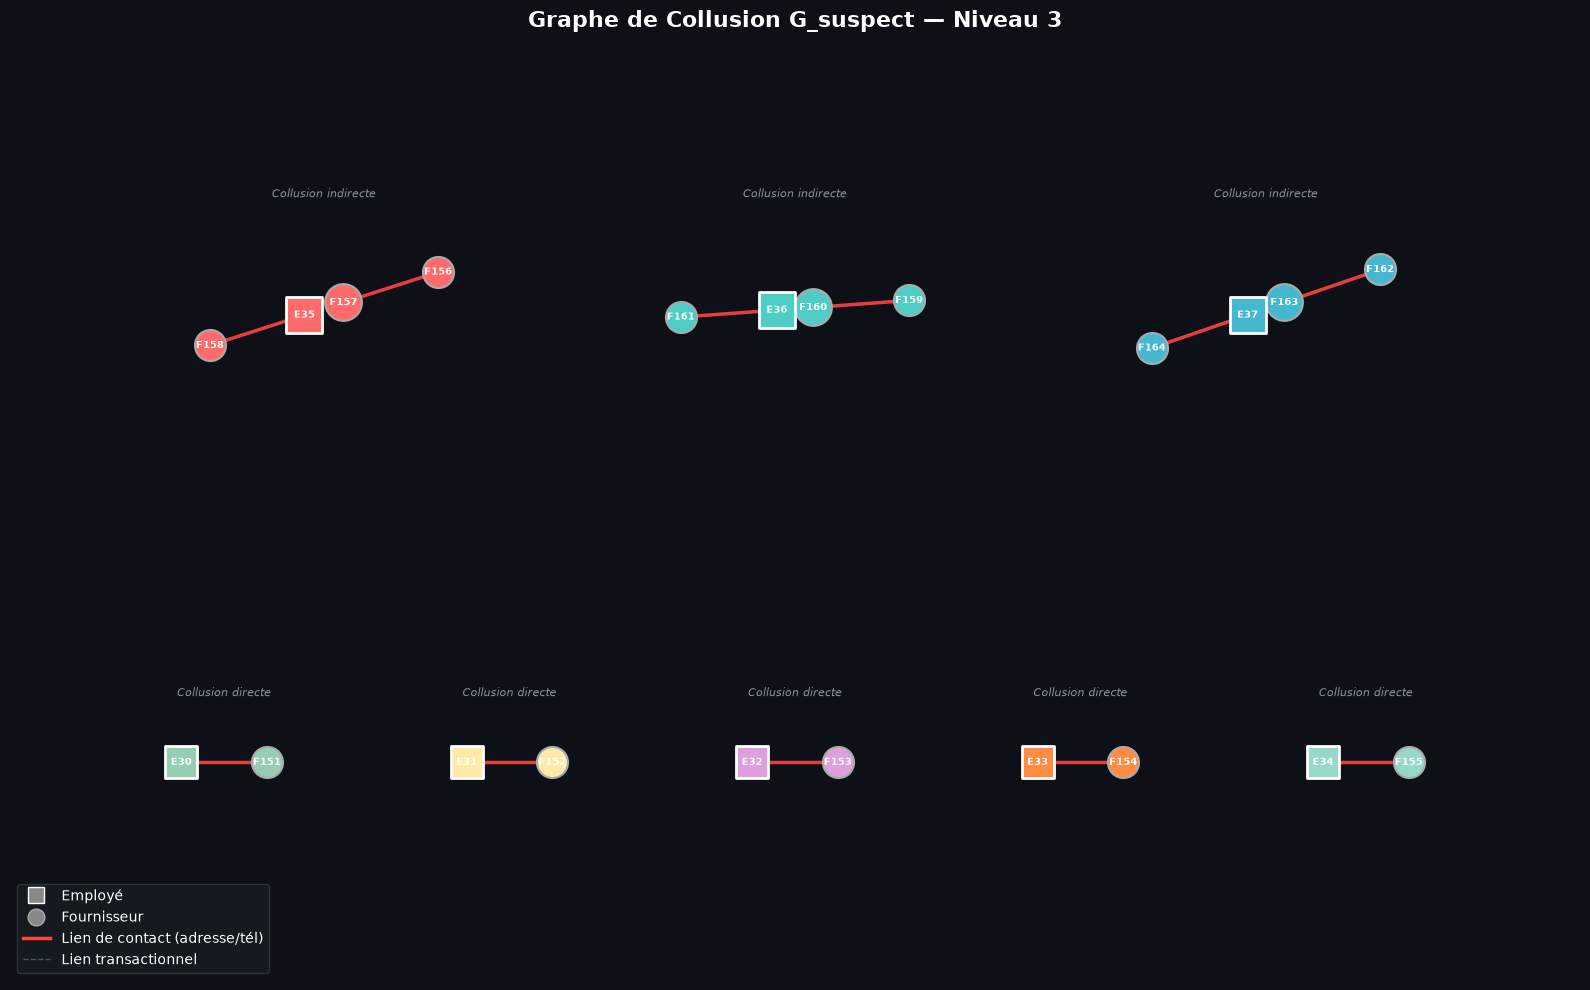

In [14]:
# ================================================================
# 2.4 VISUALISATION DU GRAPHE G_suspect
# ================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# ── Palette de couleurs par communauté ──
cluster_colors = [
    '#FF6B6B',  # rouge corail
    '#4ECDC4',  # turquoise
    '#45B7D1',  # bleu ciel
    '#96CEB4',  # vert sauge
    '#FFEAA7',  # jaune pâle
    '#DDA0DD',  # prune
    '#FF8C42',  # orange
    '#98D8C8',  # menthe
]

# ── Layout par composante pour éviter le chevauchement ──
# Positionner chaque composante séparément
pos = {}
comps_sorted = sorted(list(nx.connected_components(G_suspect)), key=len, reverse=True)

# Grille de placement : 3 indirects en haut, 5 directs en bas
placements = [
    (0.17, 0.72),  # indirect 1
    (0.50, 0.72),  # indirect 2
    (0.83, 0.72),  # indirect 3
    (0.10, 0.22),  # direct 1
    (0.30, 0.22),  # direct 2
    (0.50, 0.22),  # direct 3
    (0.70, 0.22),  # direct 4
    (0.90, 0.22),  # direct 5
]

for idx, comp in enumerate(comps_sorted):
    subG = G_suspect.subgraph(comp)
    center_x, center_y = placements[idx] if idx < len(placements) else (0.5, 0.5)
    
    if len(comp) <= 2:
        # Paire directe : disposition horizontale
        nodes_list = sorted(comp)
        for j, node in enumerate(nodes_list):
            offset_x = (j - 0.5) * 0.06
            pos[node] = (center_x + offset_x, center_y)
    else:
        # Cluster indirect : layout circulaire centré
        sub_pos = nx.spring_layout(subG, seed=42, scale=0.08, center=(center_x, center_y))
        pos.update(sub_pos)

# ── Dessiner les arêtes ──
for u, v, data in G_suspect.edges(data=True):
    types = data.get('link_types', set())
    contact_types = types - {'transaction'}
    
    if contact_types:
        # Arête de contact : rouge, épaisse
        edge_color = '#FF4444'
        edge_width = 2.5
        edge_style = 'solid'
        edge_alpha = 0.9
    else:
        # Arête de transaction : grise, fine
        edge_color = '#555555'
        edge_width = 1.0
        edge_style = 'dashed'
        edge_alpha = 0.5
    
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
            color=edge_color, linewidth=edge_width, linestyle=edge_style,
            alpha=edge_alpha, zorder=1)

# ── Dessiner les nœuds ──
for node in G_suspect.nodes():
    node_data = G_suspect.nodes[node]
    comm_id = node_community[node]
    color = cluster_colors[comm_id % len(cluster_colors)]
    x, y = pos[node]
    deg = degree_dict[node]
    size = 300 + deg * 200  # Taille proportionnelle au degré
    
    if node_data['type'] == 'employe':
        # Carré pour employé
        marker = 's'
        edgecolor = '#FFFFFF'
        linewidth = 2
    else:
        # Rond pour fournisseur
        marker = 'o'
        edgecolor = '#AAAAAA'
        linewidth = 1.5
    
    ax.scatter(x, y, c=color, s=size, marker=marker,
              edgecolors=edgecolor, linewidths=linewidth, zorder=3)
    
    # Étiquette
    label = node.replace('FRS-00', 'F').replace('EMP-0', 'E')
    ax.annotate(label, (x, y), fontsize=7, fontweight='bold',
               color='white', ha='center', va='center', zorder=4)

# ── Légende ──
legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#888888',
           markeredgecolor='white', markersize=12, label='Employé', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#888888',
           markeredgecolor='#AAAAAA', markersize=12, label='Fournisseur', linewidth=0),
    Line2D([0], [0], color='#FF4444', linewidth=2.5, label='Lien de contact (adresse/tél)'),
    Line2D([0], [0], color='#555555', linewidth=1, linestyle='dashed', label='Lien transactionnel'),
]

leg = ax.legend(handles=legend_elements, loc='lower left', fontsize=10,
               facecolor='#161b22', edgecolor='#30363d', labelcolor='white',
               framealpha=0.9)

# ── Annotations de clusters ──
for idx, comp in enumerate(comps_sorted):
    center_x, center_y = placements[idx] if idx < len(placements) else (0.5, 0.5)
    n_nodes = len(comp)
    if n_nodes > 2:
        label = f"Collusion indirecte"
    else:
        label = f"Collusion directe"
    ax.text(center_x, center_y + (0.12 if n_nodes > 2 else 0.07),
            label, fontsize=8, color='#8b949e', ha='center', va='bottom',
            fontstyle='italic')

# ── Titre et style ──
ax.set_title('Graphe de Collusion G_suspect \u2014 Niveau 3',
            fontsize=16, fontweight='bold', color='white', pad=20)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.02, 1.0)
ax.axis('off')

plt.tight_layout()
plt.savefig('../reports/figures/graphe_collusion.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
print("Graphe sauv\u00e9 : reports/figures/graphe_collusion.png")
plt.show()

---
## Étape 3 — Test de robustesse sur le graphe complet G

**Objectif :** Tester la détection de communautés de Louvain sur le graphe complet `G` (non filtré) pour voir si les signaux de collusion résistent au bruit des transactions normales.

In [15]:
# ================================================================
# 3.1 DÉTECTION DE COMMUNAUTÉS (LOUVAIN) SUR G COMPLET
# ================================================================

# Louvain sur le graphe complet G
communities_full = louvain_communities(G, seed=42)
communities_full = sorted(communities_full, key=len, reverse=True)

print(f"Nombre de communautés détectées sur G complet : {len(communities_full)}")
print()

# On recherche où atterrissent les nœuds de nos 8 clusters injectés
# Reprenons nos 8 clusters initiaux (tels que détectés dans G_suspect)
print("Répartition des clusters de collusion dans les communautés du graphe complet :")
print("=" * 80)

# Construire un dictionnaire {nœud: id_communaute_g_complet}
node_to_full_comm = {}
for comm_id, comm in enumerate(communities_full):
    for node in comm:
        node_to_full_comm[node] = comm_id

# Vérifions chaque cluster injecté (les 8 composantes de G_suspect)
for idx, comp in enumerate(comps):
    comp_nodes_sorted = sorted(list(comp))
    # Trouver l'ID de la communauté dans G_complet pour chaque nœud
    comm_ids = [node_to_full_comm[n] for n in comp_nodes_sorted]
    unique_comms = set(comm_ids)
    
    status = "✅ Regroupés" if len(unique_comms) == 1 else f"❌ Dispersés sur {len(unique_comms)} communautés"
    print(f"Cluster injecté {idx+1} {comp_nodes_sorted}:")
    print(f"  Statut : {status}")
    print(f"  Communautés (G complet) assignées : {comm_ids}")
    if len(unique_comms) > 1:
        print(f"  -> Bruit transactionnel trop fort, séparation du cluster !")
    print("-" * 60)


Nombre de communautés détectées sur G complet : 14

Répartition des clusters de collusion dans les communautés du graphe complet :
Cluster injecté 1 ['EMP-030', 'FRS-00151']:
  Statut : ✅ Regroupés
  Communautés (G complet) assignées : [6, 6]
------------------------------------------------------------
Cluster injecté 2 ['EMP-031', 'FRS-00152']:
  Statut : ✅ Regroupés
  Communautés (G complet) assignées : [8, 8]
------------------------------------------------------------
Cluster injecté 3 ['EMP-032', 'FRS-00153']:
  Statut : ✅ Regroupés
  Communautés (G complet) assignées : [9, 9]
------------------------------------------------------------
Cluster injecté 4 ['EMP-033', 'FRS-00154']:
  Statut : ✅ Regroupés
  Communautés (G complet) assignées : [11, 11]
------------------------------------------------------------
Cluster injecté 5 ['EMP-034', 'FRS-00155']:
  Statut : ✅ Regroupés
  Communautés (G complet) assignées : [4, 4]
------------------------------------------------------------
Cl

### 3.2 Visualisation du Graphe Complet

Graphe complet sauvé : reports/figures/graphe_complet_avec_clusters.png


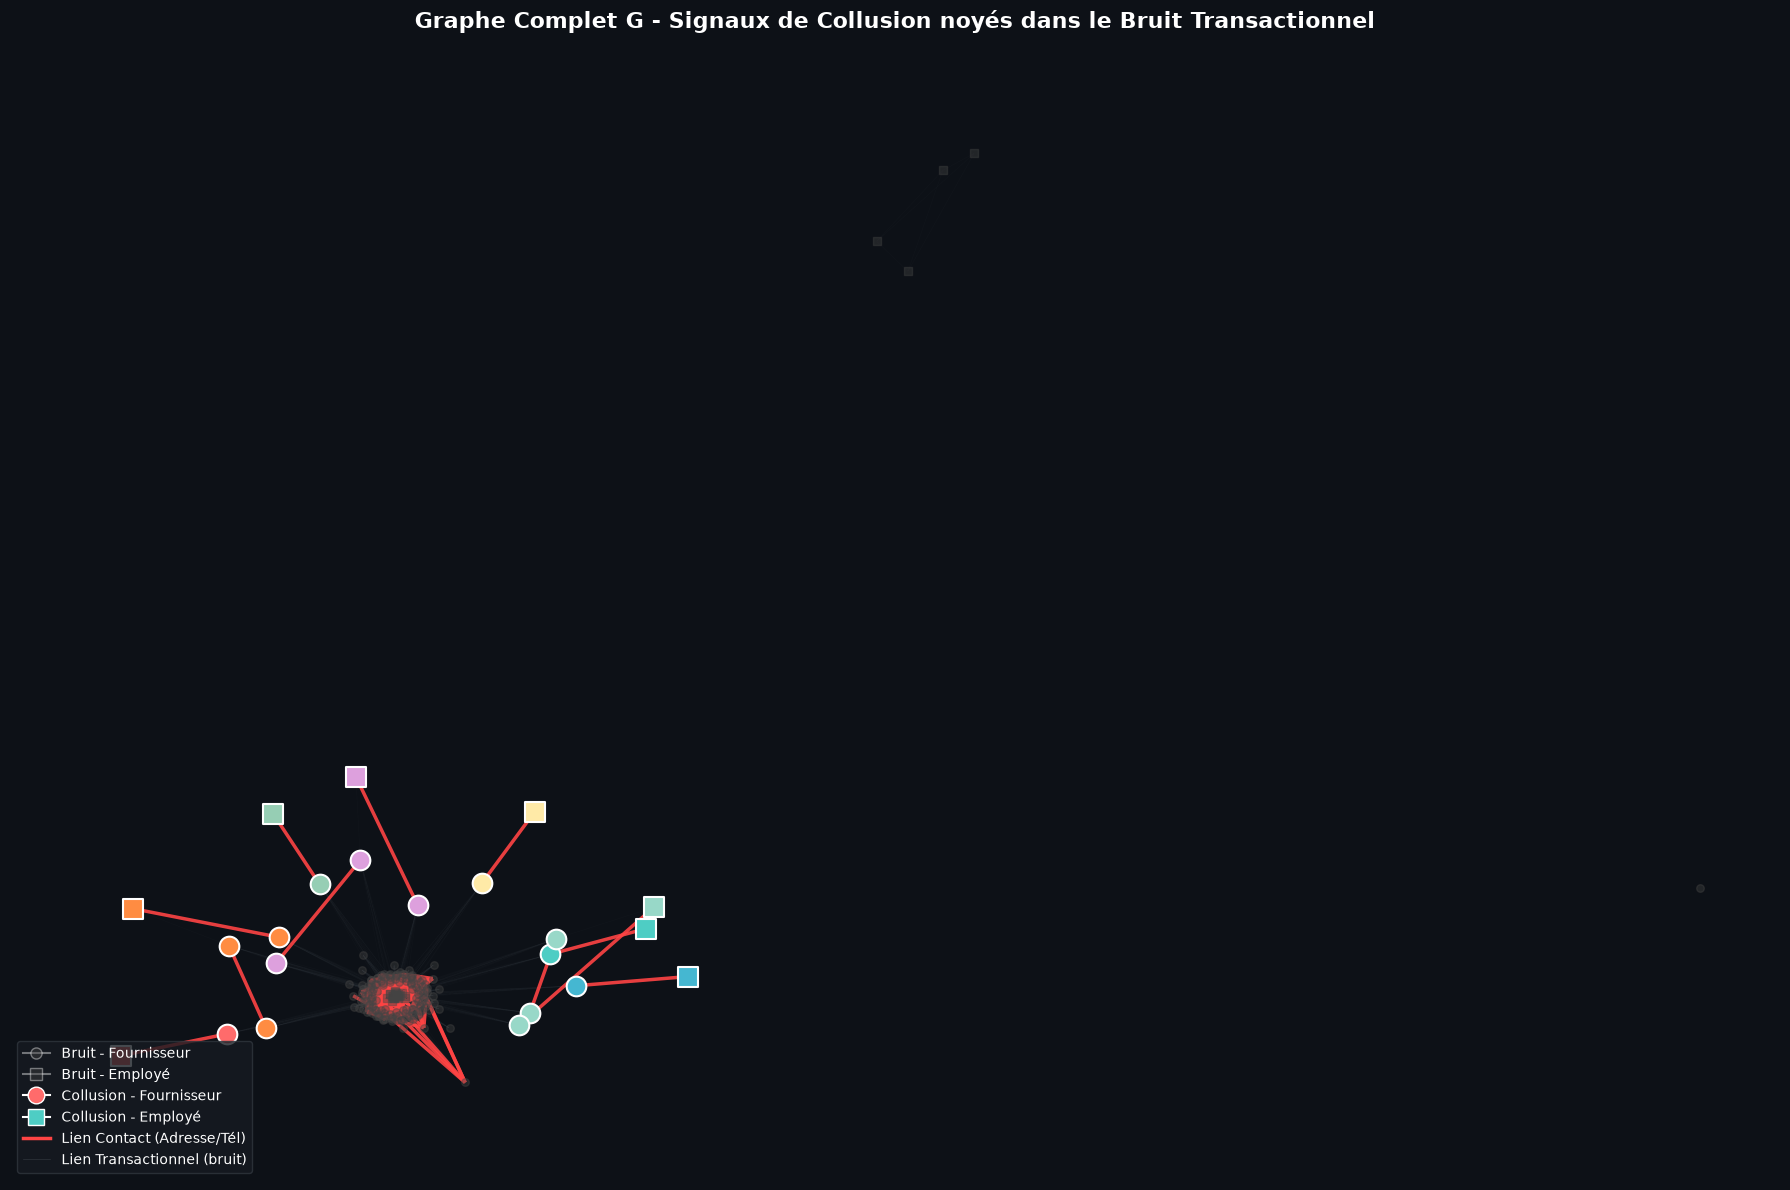

In [16]:
# ================================================================
# 3.2 VISUALISATION DU GRAPHE COMPLET G
# ================================================================
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

# On prépare la figure
fig, ax = plt.subplots(1, 1, figsize=(18, 12))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# Layout du graphe complet (peut prendre un peu de temps à calculer)
# Spring layout donne un bon résultat pour les réseaux denses
pos_full = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

# Récupérer les nœuds suspects (les 22 nœuds de nos 8 clusters injectés)
suspect_nodes = set(G_suspect.nodes())

# Dessiner les arêtes "normales" (transaction) vs "suspectes" (contact)
edges_normal = []
edges_suspect = []
for u, v, data in G.edges(data=True):
    types = data.get('link_types', set())
    contact_types = types - {'transaction'}
    
    # Exclure la collision aléatoire pour l'affichage 'contact' rouge
    pair = tuple(sorted([u, v]))
    if pair in exclusion_collision or (pair[1], pair[0]) in exclusion_collision:
         edges_normal.append((u, v))
         continue
    if u in coinc_refs and v in coinc_refs:
         edges_normal.append((u, v))
         continue
         
    if contact_types:
        edges_suspect.append((u, v))
    else:
        edges_normal.append((u, v))

# Dessiner d'abord les arêtes normales (bruit de fond) en gris très transparent
nx.draw_networkx_edges(G, pos_full, edgelist=edges_normal, ax=ax, edge_color='#30363d', alpha=0.1, width=0.5)

# Dessiner les arêtes de contact (suspectes) en rouge
nx.draw_networkx_edges(G, pos_full, edgelist=edges_suspect, ax=ax, edge_color='#FF4444', alpha=0.9, width=2.5)

# Séparer les nœuds "bruit" des nœuds "suspects"
normal_nodes_frs = [n for n in G.nodes() if n not in suspect_nodes and G.nodes[n]['type'] == 'fournisseur']
normal_nodes_emp = [n for n in G.nodes() if n not in suspect_nodes and G.nodes[n]['type'] == 'employe']

# Dessiner le bruit de fond (fournisseurs = cercles, employés = carrés)
nx.draw_networkx_nodes(G, pos_full, nodelist=normal_nodes_frs, ax=ax, node_color='#444444', node_size=30, node_shape='o', alpha=0.4)
nx.draw_networkx_nodes(G, pos_full, nodelist=normal_nodes_emp, ax=ax, node_color='#444444', node_size=30, node_shape='s', alpha=0.4)

# Dessiner les nœuds suspects en les coloriant selon leur cluster G_suspect
for idx, comp in enumerate(comps):
    comp_list = list(comp)
    suspect_frs = [n for n in comp_list if G.nodes[n]['type'] == 'fournisseur']
    suspect_emp = [n for n in comp_list if G.nodes[n]['type'] == 'employe']
    
    color = cluster_colors[idx % len(cluster_colors)]
    
    if suspect_frs:
        nx.draw_networkx_nodes(G, pos_full, nodelist=suspect_frs, ax=ax, node_color=color, node_size=200, node_shape='o', edgecolors='white', linewidths=1.5)
    if suspect_emp:
        nx.draw_networkx_nodes(G, pos_full, nodelist=suspect_emp, ax=ax, node_color=color, node_size=200, node_shape='s', edgecolors='white', linewidths=1.5)

# Légende
legend_elements_full = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#444444', markersize=8, label='Bruit - Fournisseur', alpha=0.4),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#444444', markersize=8, label='Bruit - Employé', alpha=0.4),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF6B6B', markeredgecolor='white', markersize=12, label='Collusion - Fournisseur'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#4ECDC4', markeredgecolor='white', markersize=12, label='Collusion - Employé'),
    Line2D([0], [0], color='#FF4444', linewidth=2.5, label='Lien Contact (Adresse/Tél)'),
    Line2D([0], [0], color='#30363d', linewidth=0.5, label='Lien Transactionnel (bruit)'),
]
ax.legend(handles=legend_elements_full, loc='lower left', fontsize=10, facecolor='#161b22', edgecolor='#30363d', labelcolor='white')

ax.set_title("Graphe Complet G - Signaux de Collusion noyés dans le Bruit Transactionnel", fontsize=16, fontweight='bold', color='white', pad=20)
ax.axis('off')

plt.tight_layout()
plt.savefig('../reports/figures/graphe_complet_avec_clusters.png', dpi=150, bbox_inches='tight', facecolor='#0d1117', edgecolor='none')
print("Graphe complet sauvé : reports/figures/graphe_complet_avec_clusters.png")
plt.show()